In [1]:
from datasets import load_dataset

ds = load_dataset("DavidVivancos/MindBigData2022_MNIST_EP")
train = ds["train"]
test = ds["test"]

df_train = train.to_pandas()

In [2]:
print(df_train.shape)  # (52022, 3585)

# Kolumny to 'label' - cyfra od 0 do 9, lub -1 gdy brak stymulacji
# Pozostałe 3584 kolumn to dane EEG z 14 elektrod x 256 próbek czasowych (14*256=3584)
# Próbka czasowa to 2 sekundy nagrania EEG, bo częstotliwość próbkowania to 128 Hz (256 próbek / 128 Hz = 2 sekundy)
# Czyli wiersz reprezentuje jedno nagranie napięcia EEG z 14 elektrod przez 2 sekundy
# Format kolumn to {kanał}-{numer_próbki}, np. 'AF3-0'

# Kanały EEG w kolejności kolumn:
# | Nr | Kanał | Pozycja        | Region mózgu              |
# |----|-------|----------------|---------------------------|
# | 1  | AF3   | L przedczołowy | planowanie, uwaga         |
# | 2  | F7    | L czołowy bocz.| język                     |
# | 3  | F3    | L czołowy      | decyzje                   |
# | 4  | FC5   | L czoł-centr.  | motoryka                  |
# | 5  | T7    | L skroniowy    | pamięć słuchowa           |
# | 6  | P7    | L ciemieniowy  | percepcja wzrokowa        |
# | 7  | O1    | L potyliczny   | kora wzrokowa (!)         |
# | 8  | O2    | R potyliczny   | kora wzrokowa (!)         |
# | 9  | P8    | R ciemieniowy  | percepcja wzrokowa        |
# | 10 | T8    | R skroniowy    | pamięć słuchowa           |
# | 11 | FC6   | R czoł-centr.  | motoryka                  |
# | 12 | F4    | R czołowy      | decyzje                   |
# | 13 | F8    | R czołowy bocz.| język                     |
# | 14 | AF4   | R przedczołowy | planowanie, uwaga         |
# L = lewa półkula, R = prawa półkula
# O1/O2 to kora wzrokowa - kluczowe kanały dla rozpoznawania bodźców wizualnych

print(df_train.columns)
print(df_train["label"].value_counts())

(52022, 3585)
Index(['label', 'AF3-0', 'AF3-1', 'AF3-2', 'AF3-3', 'AF3-4', 'AF3-5', 'AF3-6',
       'AF3-7', 'AF3-8',
       ...
       'AF4-246', 'AF4-247', 'AF4-248', 'AF4-249', 'AF4-250', 'AF4-251',
       'AF4-252', 'AF4-253', 'AF4-254', 'AF4-255'],
      dtype='str', length=3585)
label
 3    5294
 5    5256
 9    5250
 8    5241
 6    5218
 0    5212
 2    5196
 1    5080
 4    5079
 7    5069
-1     127
Name: count, dtype: int64


In [3]:
labels = df_train["label"].values  # (52022,)
eeg = df_train.drop("label", axis=1, inplace=False).values  # (52022, 3584)
# Reshape, aby mieć dane w postaci (próbki, kanały, epoki_czasowe)
eeg = eeg.reshape(-1, 14, 256)  # (52022, 14, 256)

<Axes: xlabel='label'>

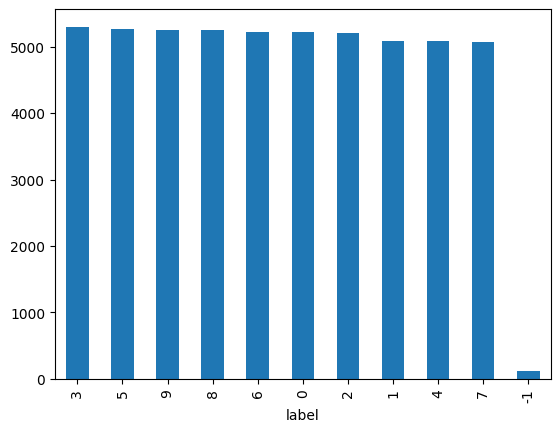

In [4]:
# Dobre zbalansowanie klas
df_train["label"].value_counts().plot(kind="bar")

In [5]:
print("Min per kanał")
print(eeg.min(axis=(0, 2)))
print("Max per kanał")
print(eeg.max(axis=(0, 2)))
print("Mean per kanał")
print(eeg.mean(axis=(0, 2)))
print("Std per kanał")
print(eeg.std(axis=(0, 2)))

print("Globalne:")
print("Min:", eeg.min())
print("Max:", eeg.max())
print("Mean:", eeg.mean())
print("Std:", eeg.std())

Min per kanał
[1852.516352 1852.516352 2027.179488 1852.516352 1852.516352 1852.516352
 1852.516352 1852.516352 1852.516352 1852.516352 1852.516352 1852.516352
 1852.516352 1852.516352]
Max per kanał
[6147.483647 6147.483647 6147.483647 6147.483647 6147.483647 6147.483647
 6076.465482 6147.483647 6147.483647 6147.483647 5996.378698 6147.483647
 6147.483647 6147.483647]
Mean per kanał
[4381.75346485 4514.69715433 4531.48097269 4266.23136684 4491.22556455
 4191.63576556 4441.8092023  4208.40888023 4231.5673376  4497.59178694
 4202.57884125 4636.49420395 3982.01553503 4045.50076021]
Std per kanał
[114.23956494  84.91628366  34.56716629  57.5885318   96.73400341
  75.11176478  38.83796051  63.07639878  35.30917427  87.9075629
  51.0055595   68.11812565  93.71541769  54.30719385]
Globalne:
Min: 1852.516352
Max: 6147.483647
Mean: 4330.213631167655
Std: 203.02476166432737


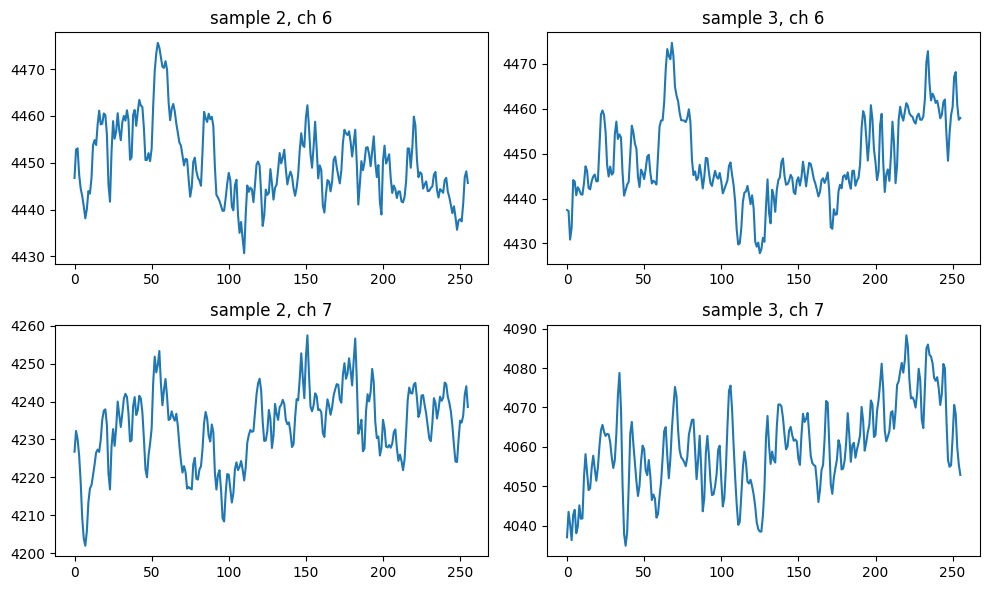

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Wizualizujemy, jak wyglądają sygnały EEG dla kanałów O1 i O2
# odpowiedzialnych za wzrok, dla dwóch przykładowych próbek dla klasy '3'

samples = [2, 3]
vision_channels = [6, 7]  # O1, O2 - kory wzrokowe

selected = eeg[labels == 3]  # cyfra '3'

for row, ch in enumerate(vision_channels):
    for col, sample_idx in enumerate(samples):
        ax = axes[row, col]

        ax.plot(selected[sample_idx][ch])
        ax.set_title(f"sample {sample_idx}, ch {ch}")

plt.tight_layout()
plt.show()

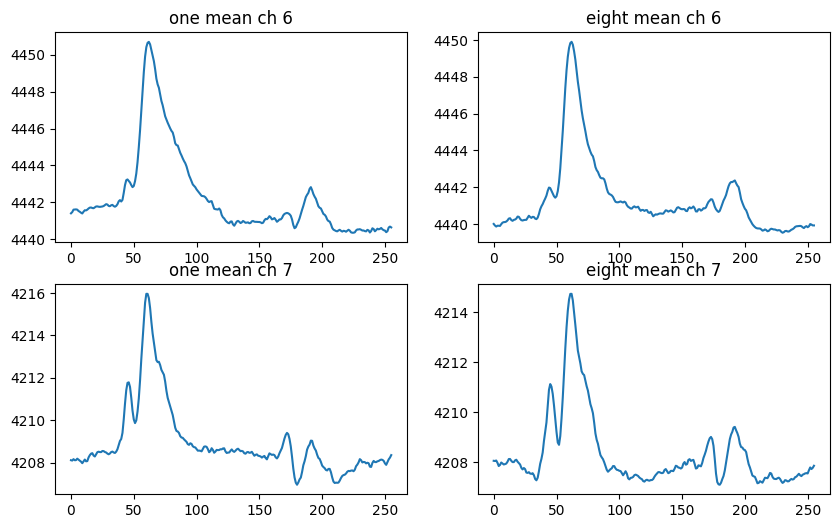

In [7]:
# Na poprzednich wykresach cięzko cokolwiek zauwazyć.
# Tutaj weźmy średnią po wszystkich próbkach, dla cyfr '1' i '8' (te cyfry chyba najbardziej się róznią od siebie).

one = eeg[labels == 1]  # (nepochs, 14, 256)
eight = eeg[labels == 8]  # (nepochs, 14, 256)

mean1 = one.mean(axis=(0))  # (14, 256)
mean2 = eight.mean(axis=(0))  # (14, 256)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

for row, ch in enumerate(vision_channels):
    ax1 = axes[row, 0]
    ax2 = axes[row, 1]

    ax1.plot(mean1[ch])
    ax1.set_title(f"one mean ch {ch}")

    ax2.plot(mean2[ch])
    ax2.set_title(f"eight mean ch {ch}")

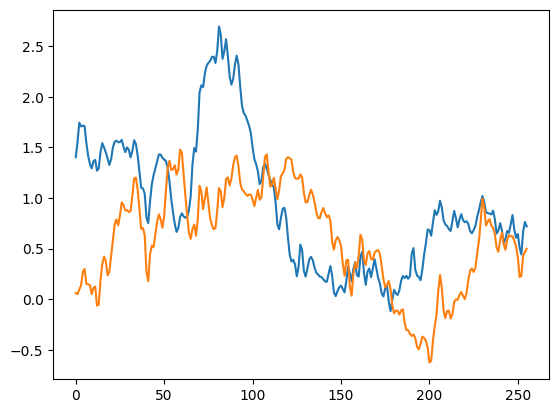

In [8]:
# Juz zaczyna widać jakieś minimalne róznice, ale nadal są bardzo subtelne.
# Zwizualizujmy roznice tych średnich.

diff = (mean1 - mean2)[vision_channels]
plt.plot(diff.T)

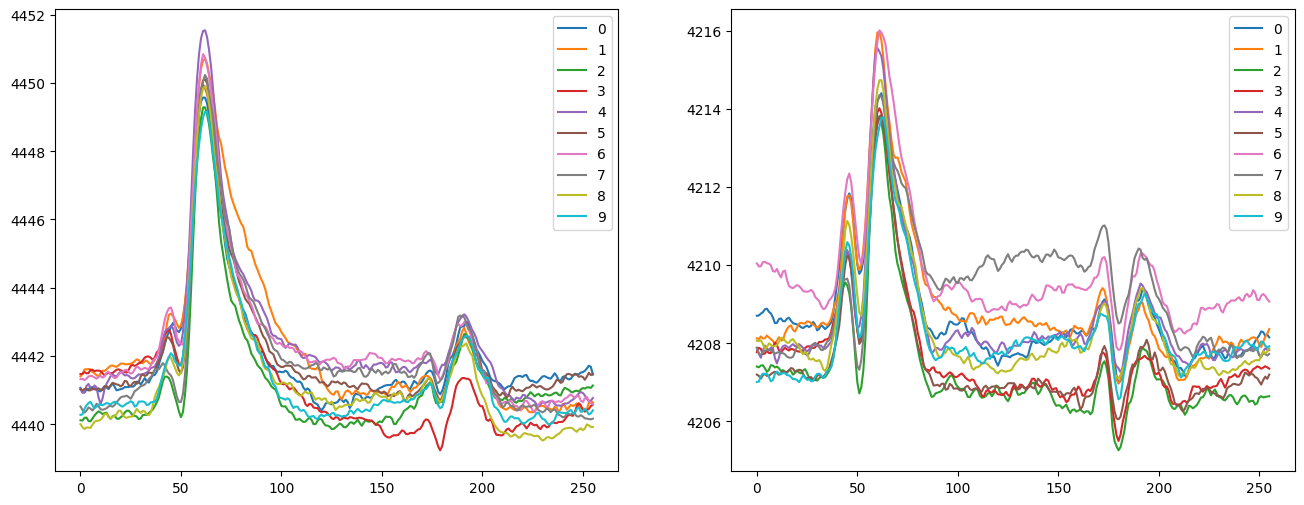

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Ok, są JAKIEŚ róznice.
# To teraz pogrupujmy średnie per cyfra dla kazdej próbki i wyświetlmy je dla kanałów O1 i O2.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

means = np.array([eeg[labels == i].mean(axis=0) for i in np.unique(labels) if i != -1])  # (10, 14, 256)

means_O1 = means[:, vision_channels[0], :]  # (10, 256)
means_O2 = means[:, vision_channels[1], :]  # (10, 256)

for i in range(10):
    axes[0].plot(means_O1[i], label=f"{i}")
    axes[1].plot(means_O2[i], label=f"{i}")
axes[0].legend()
axes[1].legend()

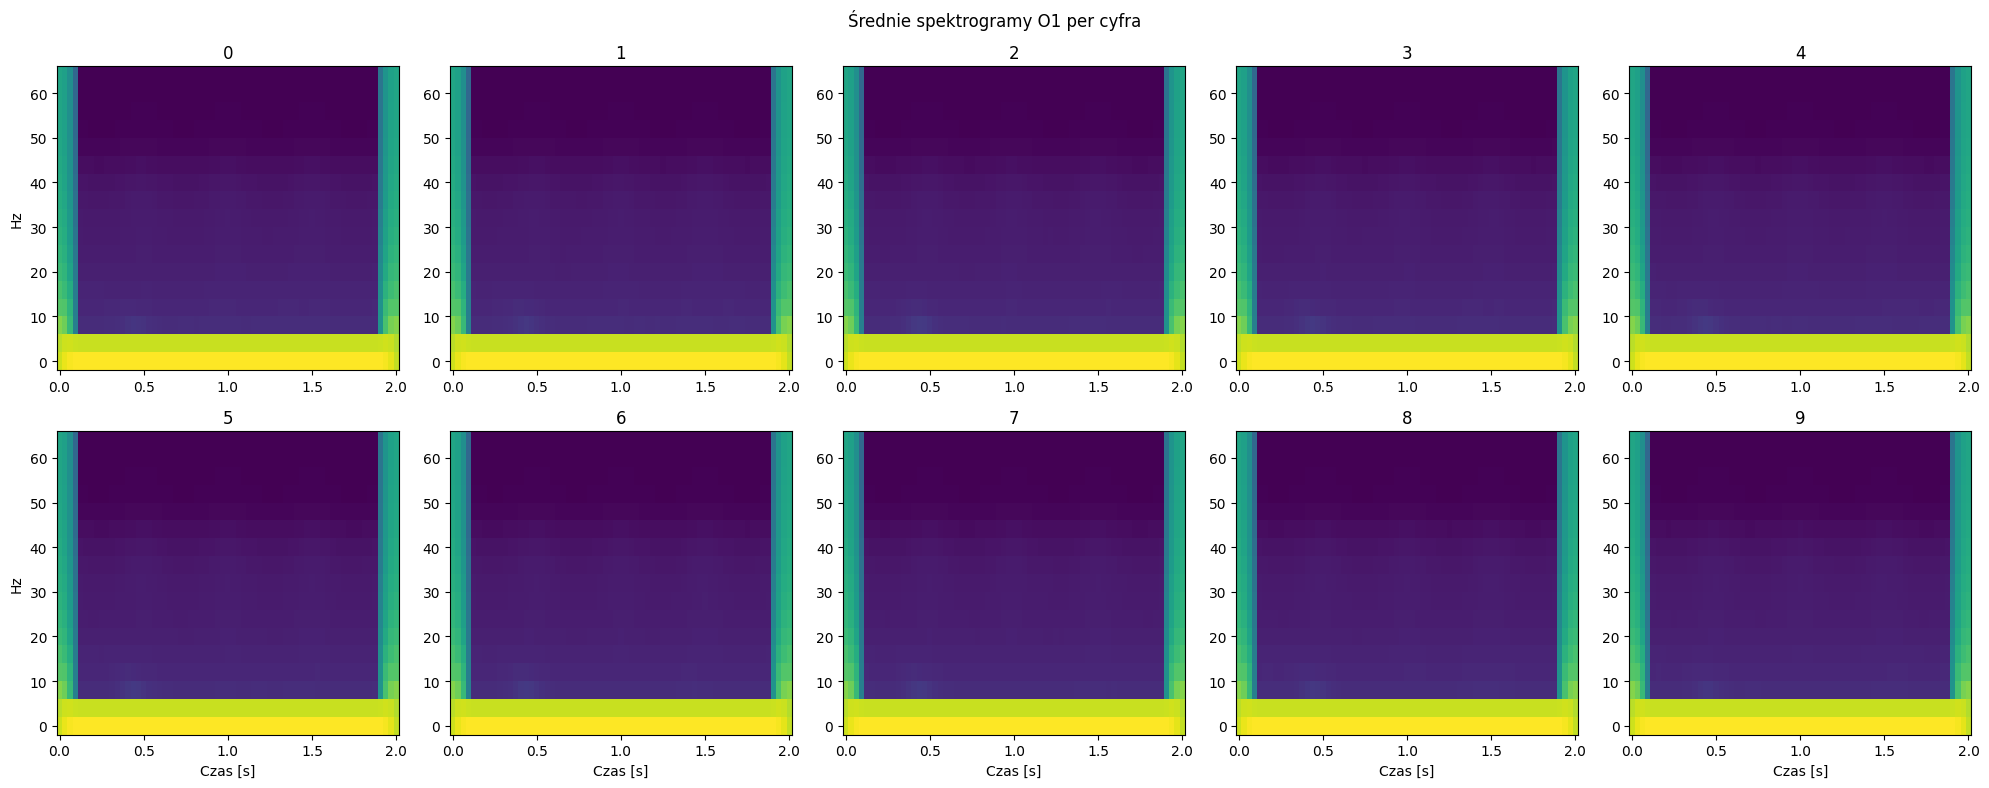

In [11]:
from scipy.signal import stft

# Spektrogram to reprezentacja sygnału EEG w dwóch wymiarach jednocześnie:
# oś X to czas, oś Y to częstotliwość [Hz], kolor = natęzenie sygnału.
# Aby to policzyć uzywamy STFT (Short-Time Fourier Transform): przesuwamy krótkie
# okno czasowe po sygnale EEG i w kazdym oknie liczymy FFT (Fast-Fourier Transform), która
# rozkłada sygnał na składowe sinusoidalne o róznych częstotliwościach. Dzięki temu widzimy
# kiedy i na jakiej częstotliwości sygnał był aktywny.
# Kumari et al. (2021) traktowali spektrogramy EEG jako obrazy 2D i trenowali CNN,
# osiągając 91.29%. Natomiast inne papery osiągały lepsze wyniki, uzywajac surowego sygnału...

# Wynik: na średnich spektrogramach per cyfra brak widocznych róznic.

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    epochs_digit = eeg[labels == digit][:, vision_channels[0], :]  # O1
    # Średni spektrogram: STFT per epoka, potem średnia amplitud
    specs = []
    for ep in epochs_digit:
        f, t, Zxx = stft(ep, fs=128, nperseg=32, noverlap=28)
        specs.append(np.abs(Zxx))
    mean_spec = np.mean(specs, axis=0)
    ax.pcolormesh(t, f, np.log1p(mean_spec), shading="auto")  # skala logarytmiczna
    ax.set_title(digit)
    if digit % 5 == 0:
        ax.set_ylabel("Hz")
    if digit >= 5:
        ax.set_xlabel("Czas [s]")
plt.suptitle("Średnie spektrogramy O1 per cyfra")
plt.tight_layout()

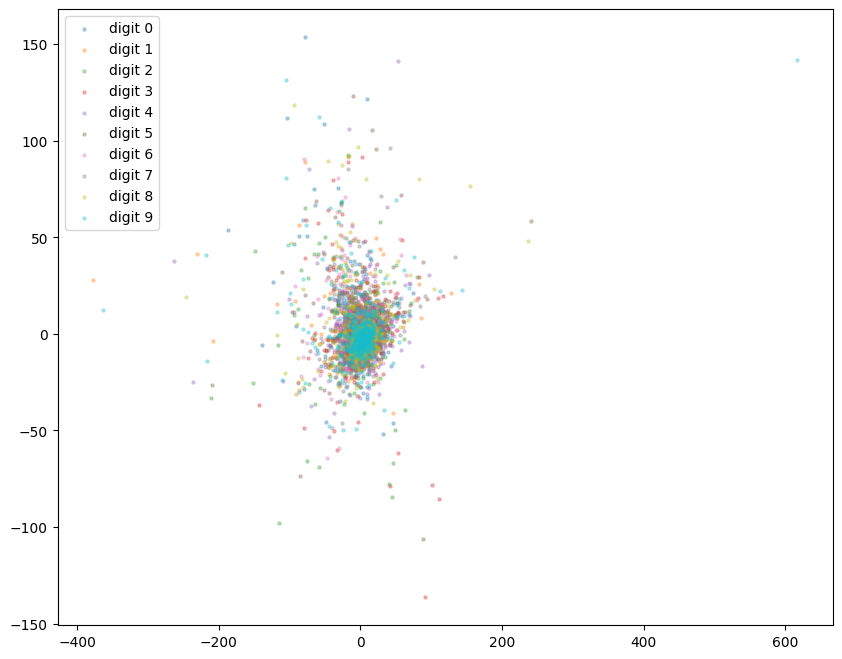

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Wrzucimy sobie 5000 próbek EEG (po 14 kanałów x 256 epok czasowych), aby zobaczyć, czy PCA będzie
# w stanie odseparować te cyfry w przestrzeni 2D. Zakładamy, ze pewnie nie.

idx = np.random.choice(len(eeg), 5000, replace=False)
X = eeg[idx].reshape(5000, -1)  # (5000, 3584)
y = labels[idx]  # (5000,)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=67)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
for i in range(10):
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"digit {i}", alpha=0.3, s=5)
plt.legend()

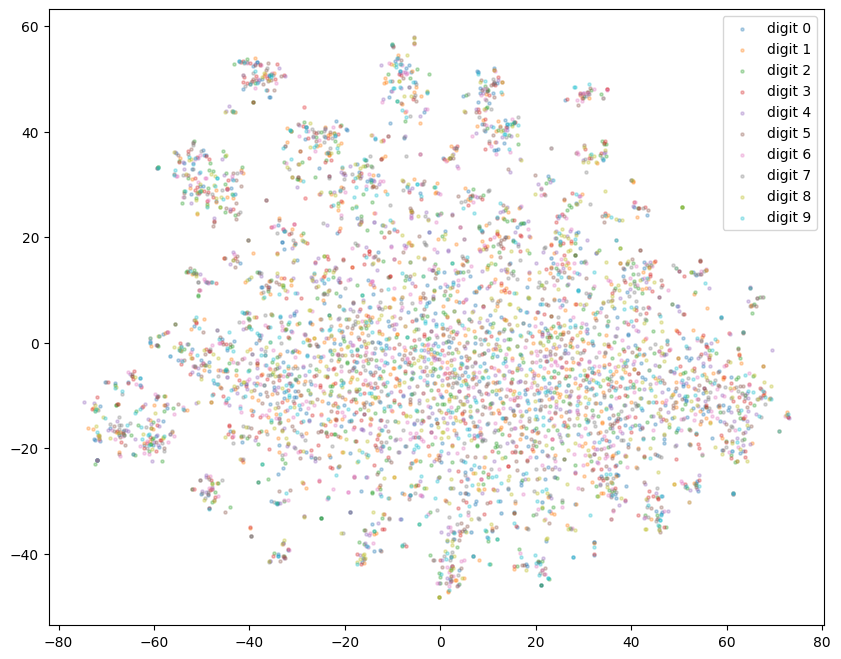

In [14]:
from sklearn.manifold import TSNE

# To teraz jeszcze TSNE, która redukuje wymiarowość danych w sposób nieliniowy, próbując
# zachować lokalne sąsiedztwa danych.

tsne = TSNE(n_components=2, random_state=67)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
for i in range(10):
    mask = y == i
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=f"digit {i}", alpha=0.3, s=5)
plt.legend()

In [ ]:
import mne
import numpy as np

sfreq = 128.0
ch_names = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
ch_types = ['eeg'] * len(ch_names)

# ADC -> wolty
eeg = eeg.astype(np.float64)
eeg = eeg - eeg.mean(axis=2, keepdims=True)   # usuń offset DC per kanał/epoka
eeg = eeg * 0.51e-6  # 0.51 µV/LSB -> wolty

eeg = mne.filter.notch_filter(eeg, Fs=sfreq, freqs=50.0, method='iir')
eeg = mne.filter.filter_data(eeg, sfreq=sfreq, l_freq=1.0, h_freq=45.0, method='iir')

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
montage = mne.channels.make_standard_montage('standard_1020')
info.set_montage(montage, match_case=False)

events = np.column_stack([
    np.arange(len(labels)),
    np.zeros(len(labels), dtype=int),
    labels.astype(int),
])
event_id = {str(d): int(d) for d in np.unique(labels)}
epochs = mne.EpochsArray(eeg, info, events=events, event_id=event_id, tmin=0.0)

epochs.set_eeg_reference('average')

epochs.drop_bad(reject={'eeg': 150e-6})  # 150 µV

print(epochs)

Setting up band-stop filter from 49 - 51 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 49.38, 50.62 Hz: -6.02, -6.02 dB

Setting up band-pass filter from 1 - 45 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 45.00 Hz: -6.02, -6.02 dB

Not setting metadata
52022 matching events found
No baseline correction applied
0 projection items activated
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
    Rejecting  epoch based on EEG : ['AF3']
    Rejecting  epoch based on EEG : ['AF4']
    Rejecting  epoch based on EEG : ['T7']
    Rejecting  epoch based on EEG : ['F8']
    Rejecting  epoch based on EEG : ['FC5']
    Rejecting  epoch

In [ ]:
# mne.viz.set_browser_backend('matplotlib')
# epochs.plot(n_epochs=5, n_channels=14, scalings={'eeg': 40e-6})

## Korelacja Pearsona między kanałami, uśrednione per cyfra

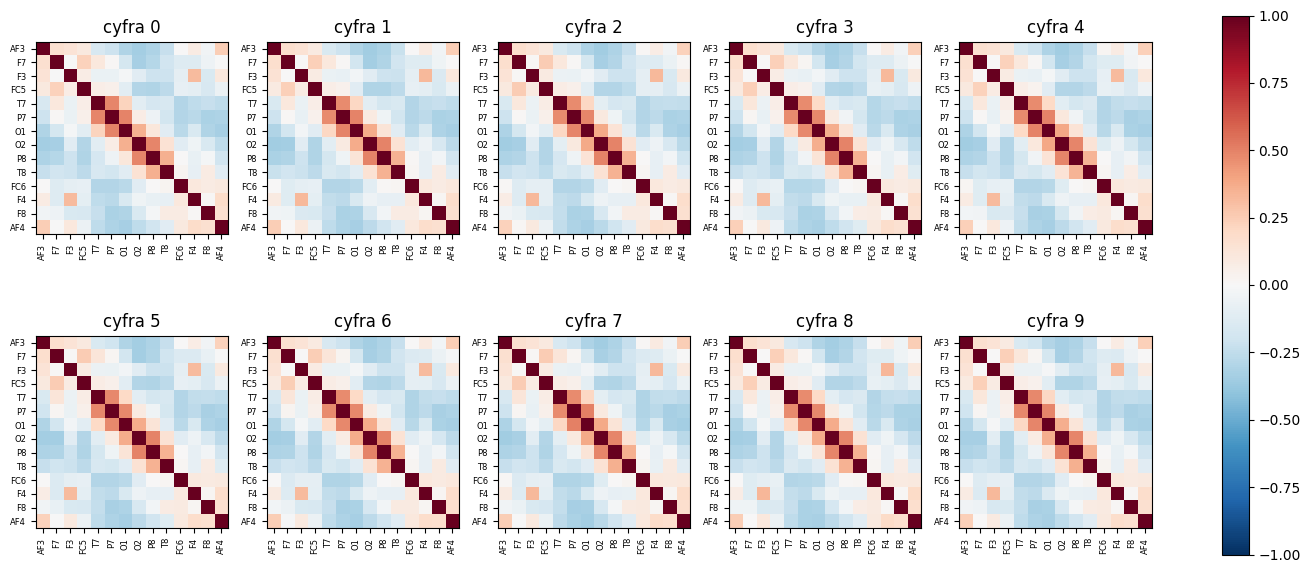

Maks. różnica między klasami: 0.03866933936098334
Średnia różnica: 0.01264617793216922


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X = epochs.get_data() # (n_epochs, 14, 256)
y = epochs.events[:, 2]

mask = y != -1
X, y = X[mask], y[mask]

ch_names = epochs.ch_names
classes = np.unique(y)

# Pearson: macierz 14x14 per epoka, uśredniona per klasa
mean_corr = {c: np.mean([np.corrcoef(e) for e in X[y == c]], axis=0) for c in classes}

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, c in zip(axes.ravel(), classes):
    im = ax.imshow(mean_corr[c], vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_title(f'cyfra {c}')
    ax.set_xticks(range(14)); ax.set_xticklabels(ch_names, rotation=90, fontsize=6)
    ax.set_yticks(range(14)); ax.set_yticklabels(ch_names, fontsize=6)
fig.colorbar(im, ax=axes.ravel().tolist())
plt.show()

all_mats = np.stack([mean_corr[c] for c in classes])
spread = np.abs(all_mats.max(axis=0) - all_mats.min(axis=0))
print("Maks. różnica między klasami:", spread.max())
print("Średnia różnica:", spread.mean())

## Pearson jest skażony volume conduction, spread na pzoiomie 0.012

## Functional connectivity - lepsze od pearsona

In [17]:
import numpy as np
from mne_connectivity import spectral_connectivity_epochs

sfreq = epochs.info['sfreq']
bands = {'theta': (4.0, 8.0), 'alpha': (8.0, 13.0)}  # pasma mało skażone EMG

def conn_per_class(method, fmin, fmax):
    out = {}
    for c in classes:
        con = spectral_connectivity_epochs(
            X[y == c], method=method, sfreq=sfreq,
            fmin=fmin, fmax=fmax, faverage=True, verbose=False)
        out[c] = con.get_data(output='dense')[:, :, 0]  # (14, 14)
    return out

for band, (fmin, fmax) in bands.items():
    conn = conn_per_class('wpli', fmin, fmax)
    mats = np.stack([conn[c] for c in classes])
    spread = np.abs(mats.max(0) - mats.min(0))
    print(f"[{band}] wPLI  maks: {spread.max():.4f}  średnia: {spread.mean():.4f}")

[theta] wPLI  maks: 0.1350  średnia: 0.0283
[alpha] wPLI  maks: 0.0933  średnia: 0.0214


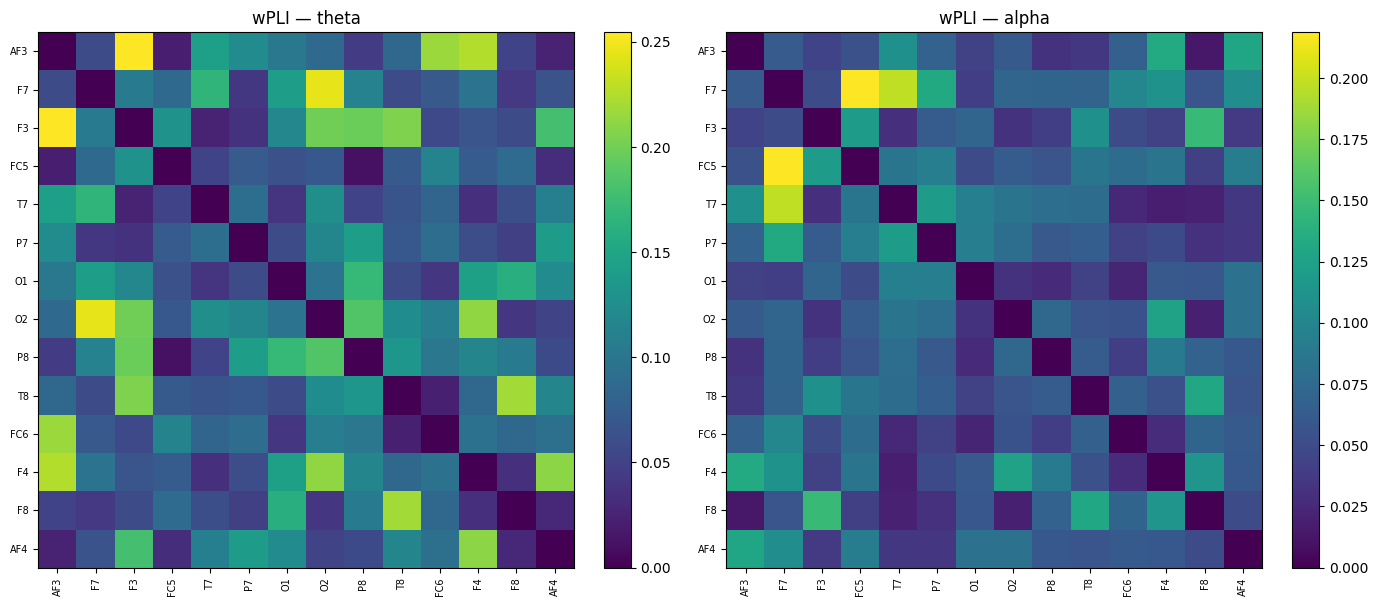

In [ ]:
ch_names = epochs.ch_names
sfreq = epochs.info['sfreq']

def wpli_matrix(data, fmin, fmax):
    con = spectral_connectivity_epochs(
        data, method='wpli', sfreq=sfreq,
        fmin=fmin, fmax=fmax, faverage=True, verbose=False)
    M = con.get_data(output='dense')[:, :, 0] # (14,14), wypełniony dolny trójkąt
    return M + M.T # symetryzacja do rysowania

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (band, (fmin, fmax)) in zip(axes, {'theta': (4, 8), 'alpha': (8, 13)}.items()):
    M = wpli_matrix(X, fmin, fmax)
    im = ax.imshow(M, vmin=0, vmax=M.max(), cmap='viridis')   # wPLI ≥ 0
    ax.set_title(f'wPLI - {band}')
    ax.set_xticks(range(14)); ax.set_xticklabels(ch_names, rotation=90, fontsize=7)
    ax.set_yticks(range(14)); ax.set_yticklabels(ch_names, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## Funkcjonalna łączność wPLI jest niska (maks ~0,2) i tylko częściowo zorganizowana: widoczne są lokalne klastry
## sąsiednich elektrod (w alfie lewy czołowo-skroniowy), obok mniej przekonujących połączeń dalekiego zasięgu. Brak
## silnej alfy potylicznej jest spójny z zadaniem wzrokowym przy otwartych oczach. Różnice łączności między cyframi
## (~0,02–0,03) są małe względem wartości samej łączności (~0,1–0,2), więc connectivity nie różnicuje cyfr — opisuje
# wspólny, słabo ustrukturyzowany stan zadania, a część frontalnego sprzężenia może odzwierciedlać resztkowe artefakty
## okoruchowe.

## DTW - odległość między uśrednionymi przebiegami poszczególnych cyfr, liczona per kanał (wyzsza wartość = bardziej rózne sygnały)

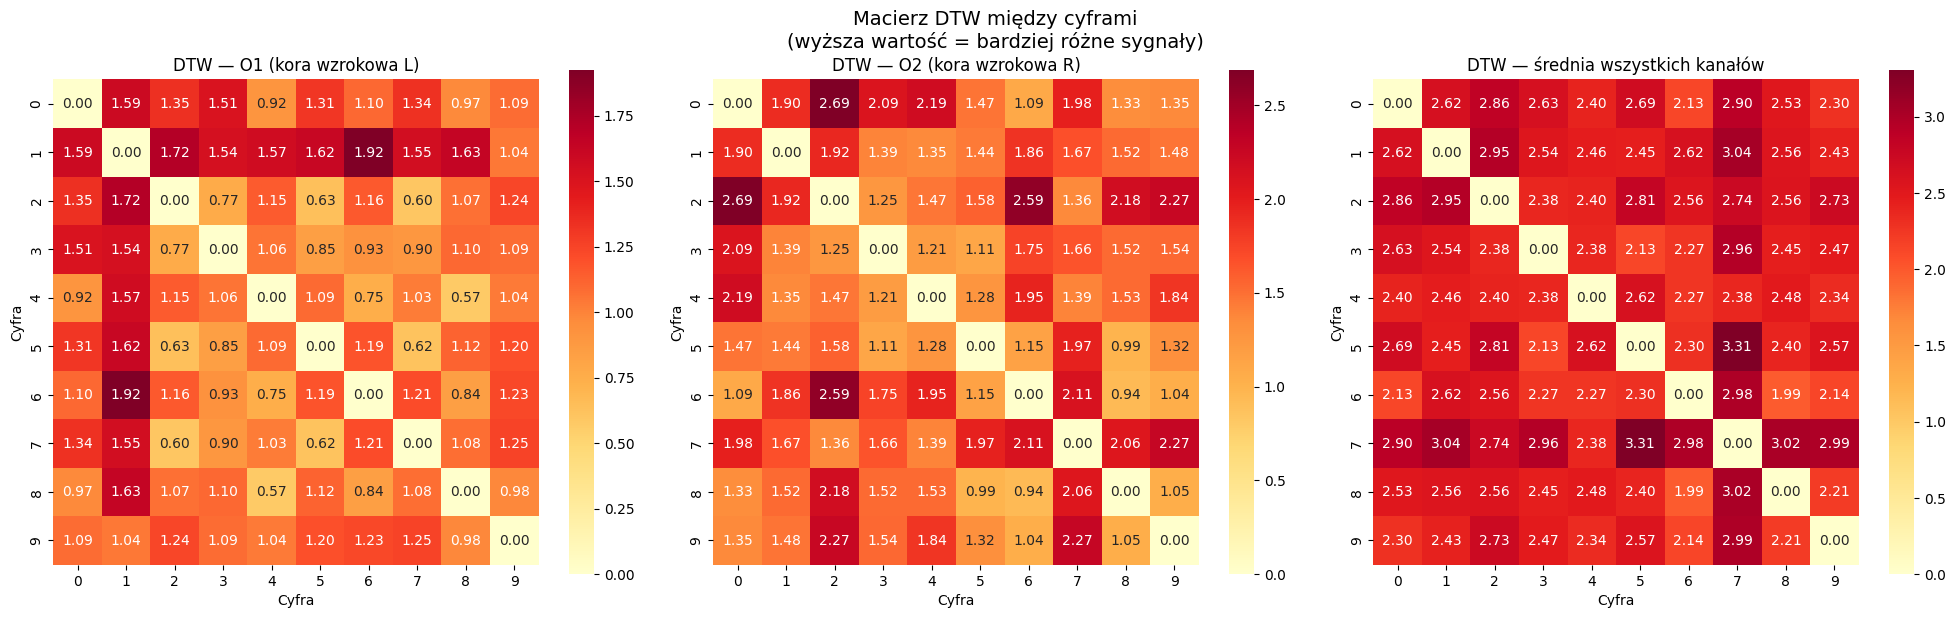

In [ ]:
import seaborn as sns
from dtaidistance import dtw
from scipy.stats import zscore

data = epochs.get_data()
y = epochs.events[:, 2]

digits = np.unique(y)
digits = digits[digits != -1]

means = np.stack([data[y == d].mean(axis=0) for d in digits])
means_z = np.nan_to_num(zscore(means, axis=2))

W = max(1, int(0.15 * means_z.shape[2])) 

def dtw_matrix_per_channel(M, ch):
    n = M.shape[0]
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = dtw.distance(
                np.ascontiguousarray(M[i, ch], dtype=np.double),
                np.ascontiguousarray(M[j, ch], dtype=np.double),
                window=W,
            )
            mat[i, j] = mat[j, i] = d
    return mat

dtw_O1 = dtw_matrix_per_channel(means_z, 6)
dtw_O2 = dtw_matrix_per_channel(means_z, 7)

dtw_all_channels = np.mean([dtw_matrix_per_channel(means_z, ch) for ch in range(14)], axis=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, mat, title in [
    (axes[0], dtw_O1, "DTW - O1 (kora wzrokowa L)"),
    (axes[1], dtw_O2, "DTW - O2 (kora wzrokowa R)"),
    (axes[2], dtw_all_channels, "DTW - średnia wszystkich kanałów"),
]:
    sns.heatmap(mat, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
                xticklabels=digits, yticklabels=digits, square=True)
    ax.set_title(title)
    ax.set_xlabel("Cyfra")
    ax.set_ylabel("Cyfra")

plt.suptitle("Macierz DTW między cyframi\n(wyższa wartość = bardziej różne sygnały)", fontsize=14)
plt.tight_layout()
plt.show()

## Żadna cyfra nie odstaje konsekwentnie na wszystkich kanałach - na O1 wyróżnia się 1, na O2 cyfra 2,
## w uśrednieniu po kanałach cyfra 7. Brak spójnego wzorca sugeruje, że różnice między uśrednionymi klasami nie są
# silne ani stabilne między kanałami.

## na których kanałach cyfry róznią się między sobą najbardziej? (który kanał rozróznia cyfry najbardziej)

In [19]:
import pandas as pd

spread = {}
for ch, name in enumerate(ch_names):
    M = dtw_matrix_per_channel(means_z, ch)
    spread[name] = M[np.triu_indices(len(digits), k=1)].mean()

ranking = pd.Series(spread).sort_values(ascending=False)
print(ranking)

## Największe różnice między uśrednionymi sygnałami cyfr występują na kanałach skroniowych (T7, T8) i czołowych,
## a najmniejsze na potylicznych (O1, O2). Rozkład ten jest niezgodny z oczekiwanym dla bodźca wzrokowego i sugeruje, że
## dominujące różnice między klasami pochodzą ze źródeł mięśniowych (EMG) i okoruchowych (EOG), a nie z kory wzrokowej.

T8     4.849369
T7     4.485136
F4     3.215574
F3     2.938178
FC5    2.886624
F7     2.606291
FC6    2.385911
P8     2.284105
F8     2.217778
AF3    1.960469
O2     1.624806
AF4    1.596513
P7     1.553639
O1     1.144137
dtype: float64
